<a href="https://colab.research.google.com/github/khanzaveriya/task-manager/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  107 non-null    object 
 1   PPT           107 non-null    int64  
 2   GDP           107 non-null    float64
 3   PRPE          107 non-null    float64
 4   OOCP          107 non-null    int64  
 5   ESE           107 non-null    int64  
 6   EPE           107 non-null    int64  
 7   UNEMP         107 non-null    float64
 8   LEB           107 non-null    float64
 9   TDP           107 non-null    int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 8.5+ KB

=========== Shape (Rows, Columns) ============
(107, 10)

========== STATISTICAL SUMMARY ==========
       Country Name           PPT           GDP        PRPE          OOCP  \
count           107  1.070000e+02  1.070000e+02  107.000000  1.070000e+02   
unique          107          

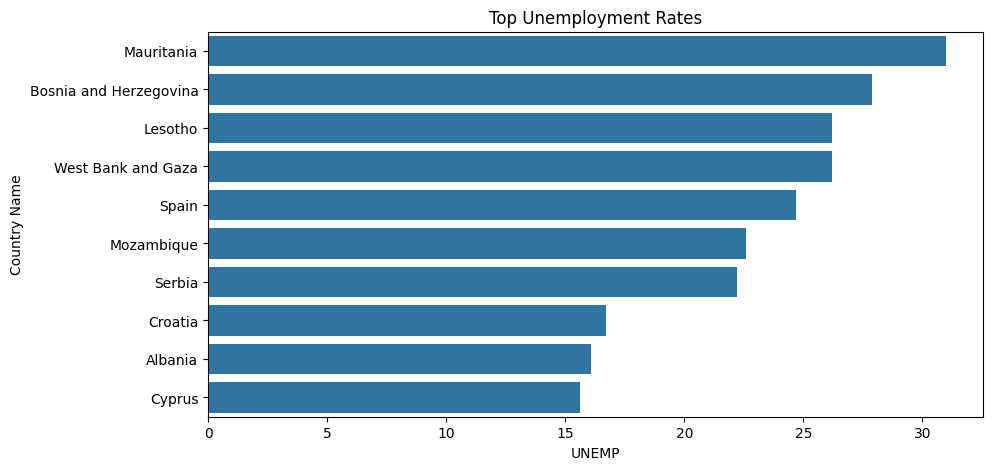

Insight:
Countries with high unemployment rates face difficulties in providing jobs to their population.


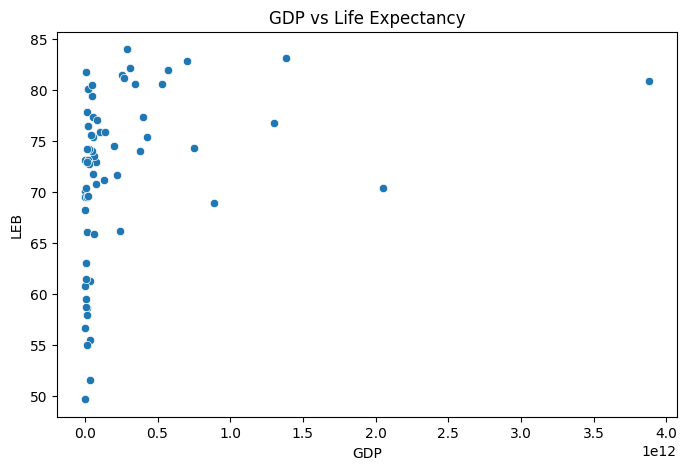

Insight:
The scatter plot indicates a positive relationship between GDP and life expectancy.

Country with Highest Education Spending:
Indonesia
Education Spending: 22586956
Insight:
The country with the highest education spending prioritizes education helping imporove literacy and future growth.

Average Unemployment Rate: 8.73
Insight:
The average unemployment rate serves as a benchmark to compare employment conditions across countries.

Country with Lowest Out-of-School Children: 
Belize
Out-of-School Children: 397
Insight:
A low number of Out-of-School children shows better access to education.

========== Conclusion ==========
The analysis shows that economic and social factors are closely linked.
Countries with stronger economies generally have better education, healthcare,
and higher life expectancy, highlighting the importance of economic growth and
investment in education.


In [10]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

df = pd.read_csv("Education Indicators 2014.csv")

# 3. Data Inspection

print("\n========== DATA INFO ==========")
df.info()

print("\n=========== Shape (Rows, Columns) ============")
print(df.shape)

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe(include='all'))

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n============ Number of Rows =============")
print(len(df))

print("\n============ Column Names ===============")
print(df.columns.tolist())

# 4. Data Cleaning

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

# Remove regional groups, income groups and aggregate records
remove_values = [
    'Arab World',
    'Central Europe ',
    'E. Asia & Pacific(-hi)',
    'Early-demographic',
    'East Asia & Pacific',
    'Europe&C. Asia(-hi)',
    'Europe &Central Asia',
    'Euro area',
    'European Union',
    'Conflict affected ',
    'High income',
    'Poor countries (HIPC)',
    'IBRD only',
    'IDA & IBRD total',
    'IDA total',
    'IDA blend',
    'IDA only',
    'Latin America(-hi)',
    'Latin America&Caribbean',
    'Least developed countries',
    'Low income',
    'Lower middle income',
    'Low & middle income',
    'Late-demographic dividend',
    'Middle East & North Africa',
    'Middle income',
    'M.East&N.Africa(-hi)',
    'OECD members',
    'Other small states',
    'Pre-demographic dividend',
    'South Asia',
    'Saharan Africa(-hi)',
    'Sub-Saharan Africa',
    'Small states',
    'East Asia&Pacific(IDA)',
    'Eur &C. Asia(IDA)',
    'Latin America(IDA)',
    'M. East&N. Africa(IDA)',
    'South Asia(IDA)',
    'Saharan Africa(IDA)',
    'Upper middle income',
    'World'
]

df = df[~df['Country Name'].isin(remove_values)]

print("\nRemaining Rows:", df.shape)

# ANALYTICAL QUESTIONS

# Q1. Which countries have the highest GDP?

top_gdp = df.nlargest(10, 'GDP')[['Country Name', 'GDP']]
print("\nTop 10 Countries by GDP\n")
print(top_gdp)
print("Insight:")
print("Countries with the highest GDP have stronger economies, higher production, and better  business activities.")

# Q2. Which countries have the highest unemployment rate?
top_unemp = df.nlargest(10, 'UNEMP')[['Country Name', 'UNEMP']]
print("\nTop 10 Countries by Unemployment Rate\n")
print(top_unemp)

plt.figure(figsize=(10,5))
sns.barplot(data=top_unemp, x='UNEMP', y='Country Name')
plt.title("Top Unemployment Rates")
plt.show()
print("Insight:")
print("Countries with high unemployment rates face difficulties in providing jobs to their population.")

# Q3. Is there a relationship between GDP and Life Expentancy

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='GDP', y='LEB')
plt.title("GDP vs Life Expectancy")
plt.show()
print("Insight:")
print("The scatter plot indicates a positive relationship between GDP and life expectancy.")

# Q4. Which country has the highest Education Spending?

highest_edu = df.loc[df['ESE'].idxmax()]

print("\nCountry with Highest Education Spending:")
print(highest_edu['Country Name'])
print("Education Spending:", highest_edu['ESE'])
print("Insight:")
print("The country with the highest education spending prioritizes education helping imporove literacy and future growth.")

# Q5. What is the average unemployment rate of all countries?

avg_unemp = df['UNEMP'].mean()
print(f"\nAverage Unemployment Rate: {avg_unemp:.2f}")
print("Insight:")
print("The average unemployment rate serves as a benchmark to compare employment conditions across countries.")

# Q6. Which country has the lowest number of Out-of-school Children?

lowest_oosc = df.loc[df['OOCP'].idxmin()]
print("\nCountry with Lowest Out-of-School Children: ")
print(lowest_oosc['Country Name'])
print("Out-of-School Children:", lowest_oosc['OOCP'])
print("Insight:")
print("A low number of Out-of-School children shows better access to education.")

print("\n========== Conclusion ==========")
print("The analysis shows that economic and social factors are closely linked.")
print("Countries with stronger economies generally have better education, healthcare,")
print("and higher life expectancy, highlighting the importance of economic growth and")
print("investment in education.")